# Classical sentiment model development

Objective: compare TRAIN-fitted TF-IDF representations and classical classifiers on the official TweetEval VALIDATION split. Macro-F1 is primary because TRAIN is imbalanced (negative 7,093; neutral 20,673; positive 17,849). TEST remains locked; this notebook never loads TEST labels or predictions. Dataset provenance and data-quality evidence are in the data-foundation reports.

TF-IDF is term frequency times inverse document frequency: it weights a term within a post and downweights terms common across many posts. For *not good*, unigrams are *not* and *good*, while the bigram *not good* retains the phrase. Character n-grams can capture contraction fragments, repeated letters and punctuation. The word token pattern keeps contractions such as *don't* together. No vocabulary or IDF was fitted on VALIDATION.

In [1]:
from pathlib import Path
import sys
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'config.py').is_file())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
import json
import pandas as pd
from IPython.display import display, Image, Markdown
from src.features import make_features, WORD_TOKEN_PATTERN
from src.evaluation import select_winner
from src.config import LABELS
comparison = pd.read_csv(root / 'reports' / 'model_comparison.csv')
metrics = json.loads((root / 'reports' / 'model_metrics.json').read_text(encoding='utf-8'))
display(comparison[['experiment_id','feature','model','validation_accuracy','validation_macro_f1','fit_seconds']])

,experiment_id,feature,model,validation_accuracy,validation_macro_f1,fit_seconds
0,exp04,combined,logistic_regression,0.7050,0.664563,15.9381
1,exp07,combined,linear_svm,0.6905,0.663119,6.8364
2,exp03,character,logistic_regression,0.6920,0.650029,12.7325
3,exp06,character,linear_svm,0.6745,0.639250,4.8643
4,exp02,word_bigram,logistic_regression,0.6805,0.636299,4.2278
5,exp05,word_bigram,linear_svm,0.6700,0.636237,1.6632
6,exp01,word_unigram,logistic_regression,0.6725,0.623554,1.3524
7,exp08,word_bigram,naive_bayes,0.6255,0.462672,0.0865
8,exp09,word_bigram,random_forest,0.5270,0.351950,1.1557


## Controlled experiments

Nine full-TRAIN runs cover word unigrams, word unigrams+bigrams, character 3–5 grams and combined word+character TF-IDF. The algorithms are Logistic Regression, LinearSVC, MultinomialNB and a bounded Random Forest. The same official TRAIN and VALIDATION rows are used throughout. Word trigrams and exhaustive search are deferred to focused tuning because the current matrix already tests the main representation differences with manageable memory.

TRAIN fits vectorizers and classifiers; VALIDATION is only transformed and scored. The ranked table and JSON below were produced by the executable pipeline, not recomputed from TEST.

In [2]:
from src.models import EXPERIMENTS
display(pd.DataFrame([vars(e) for e in EXPERIMENTS]))
display({'winner': metrics['winner']['experiment_id'],
         'macro_f1': metrics['winner']['validation_macro_f1'],
         'accuracy': metrics['winner']['validation_accuracy']})
display({'word_pattern': WORD_TOKEN_PATTERN,
         'tokenization_demo': __import__('re').findall(WORD_TOKEN_PATTERN, "don't can't isn't won't not good")})

,id,feature,model
0,exp01,word_unigram,logistic_regression
1,exp02,word_bigram,logistic_regression
2,exp03,character,logistic_regression
3,exp04,combined,logistic_regression
4,exp05,word_bigram,linear_svm
5,exp06,character,linear_svm
6,exp07,combined,linear_svm
7,exp08,word_bigram,naive_bayes
8,exp09,word_bigram,random_forest


{'winner': 'exp04', 'macro_f1': 0.6645630158401729, 'accuracy': 0.705}

{'word_pattern': "(?u)\\b\\w+(?:['’]\\w+)*\\b",
 'tokenization_demo': ["don't", "can't", "isn't", "won't", 'not', 'good']}

## Validation figures

Confusion rows are true labels, columns are predictions, ordered negative, neutral, positive. Only distinct leading candidates get confusion figures.

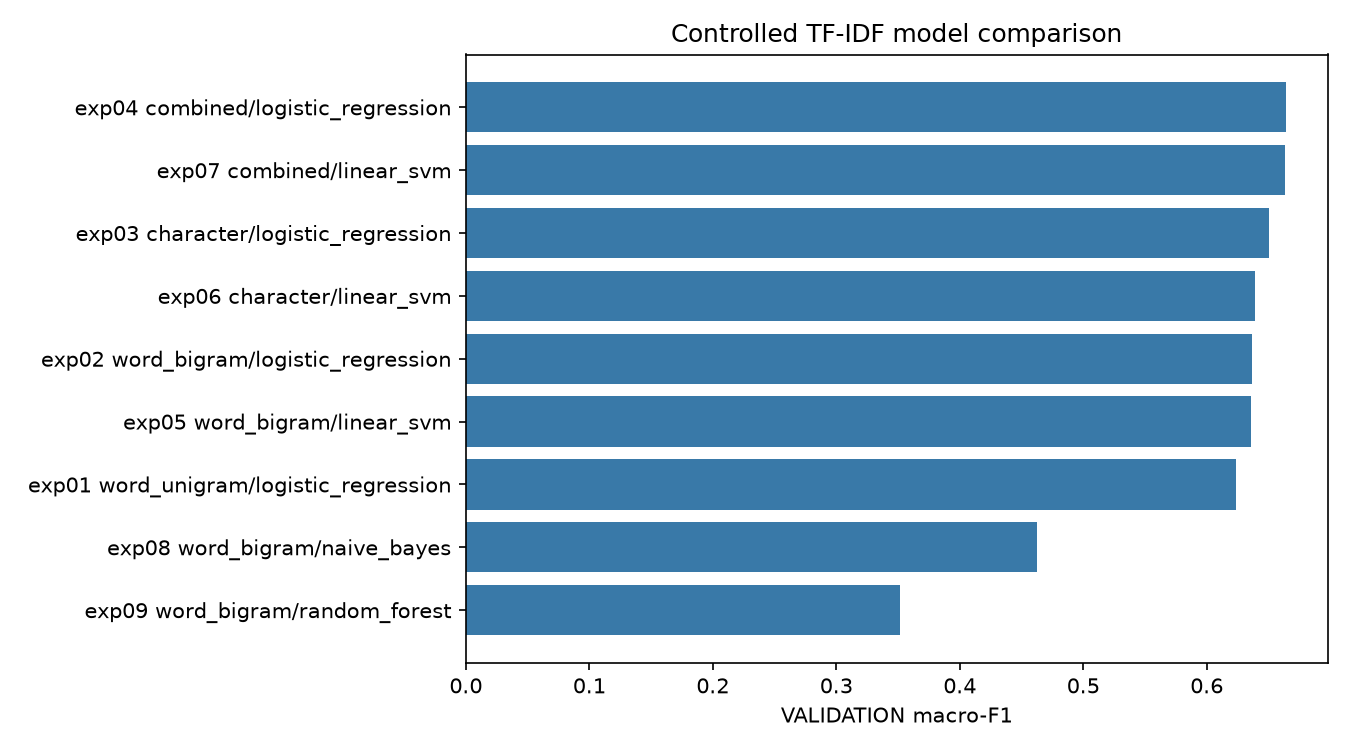

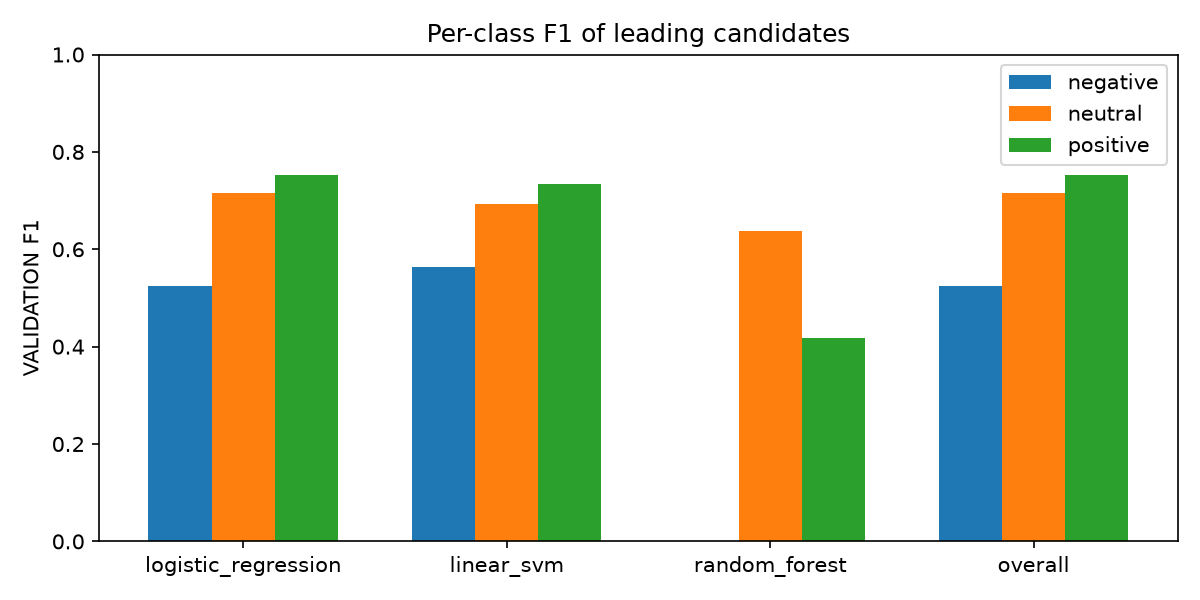

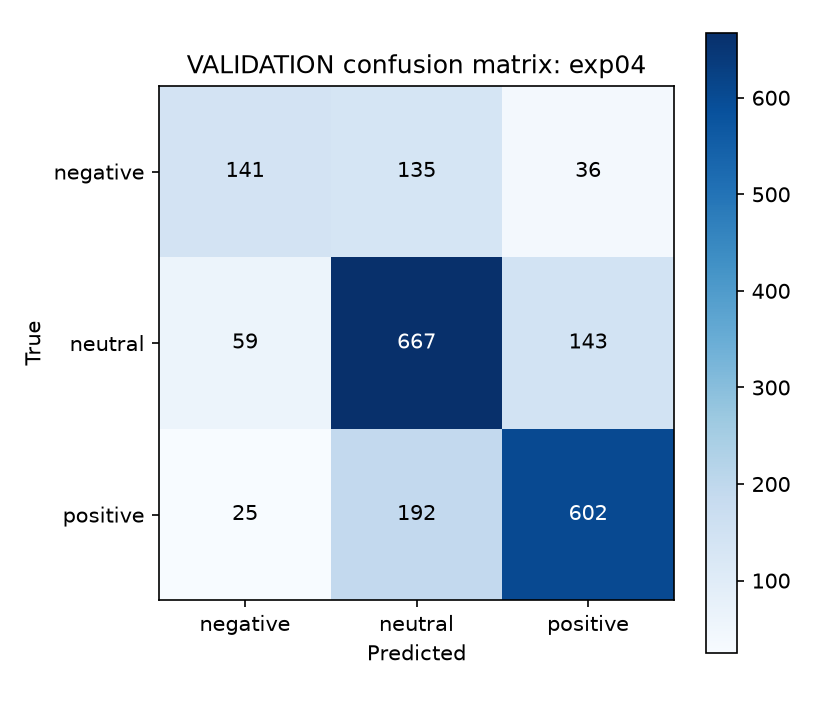

{'classes': ('negative', 'neutral', 'positive'),
 'winner_confusion': [[141, 135, 36], [59, 667, 143], [25, 192, 602]]}

In [3]:
figures = root / 'reports' / 'figures' / 'modeling'
display(Image(filename=str(figures / 'validation_macro_f1.png')))
display(Image(filename=str(figures / 'validation_per_class_f1.png')))
winner_id = metrics['winner']['experiment_id']
display(Image(filename=str(figures / f'validation_confusion_{winner_id}.png')))
display({'classes': LABELS,
         'winner_confusion': metrics['diagnostics'][winner_id]['confusion_matrix']})

## Validation errors and TRAIN-learned features

Small, ordered validation error samples indicate hypotheses, not generalizable causes. Linear coefficient rankings use TRAIN-fitted weights; they do not prove causation. No TEST examples are inspected.

In [4]:
display(Markdown((root / 'reports' / 'error_analysis.md').read_text(encoding='utf-8')))
for label, features in metrics['linear_features'][winner_id].items():
    display({label: [item['feature'] for item in features[:10]]})

# VALIDATION error analysis

Errors come from the validation-selected candidate only. Samples are ordered, small and illustrative, not representative estimates.
TEST is locked. No TEST predictions or performance were generated.

## Confusion counts

Rows are true labels; columns are predictions in negative, neutral, positive order.

[[141, 135, 36], [59, 667, 143], [25, 192, 602]]

Total errors: 590 of 2000 validation rows.

## negative to neutral: 135

- Row 2: when girls become bandwagon fans of the packers because of harry. do y'all even know who aaron rodgers is? or what a 1st down is?
- Row 10: so the thing next thursday isn't free, you'd have to pay $15 to get in since you don't go to umbc :/ and it ends at 11:30"

## negative to positive: 36

- Row 90: "judging by the traffic and complaining, i think i might be best setting for foo fighters' milton keynes gig tomorrow right now"
- Row 212: i think i may have spent too much on carmelo anthony. i only hope that his thick-framed black glasses will console me in the post-season.

## neutral to negative: 59

- Row 40: look steelers fans i know you may be upset about suisham missing that kick. just know that i heard a guy named billy cundiff is available.
- Row 85: ok big diff lmao my parents were boaters they didn't know a lot abt islam when they came. my oldest sis wore it in 1st

## neutral to positive: 143

- Row 23: in this second time i've watched ant-man and this time i was the only one that stayed for the 2nd after credits scene
- Row 27: every time i hear alright by kendrick i think it's j cole's black friday

## positive to negative: 25

- Row 148: "rahul gandhi is a ppl's leader. modimafia may try as hard, they will not be able defeat him simply becuz ppl's voice just cannot be curbed."
- Row 197: "\"""" : cupid doesn\u2019t lie but you won\u2019t know unless you give it a try\"""" wwooww.may pinaghuhugutan!"

## positive to neutral: 192

- Row 6: us 1st lady michelle obama speaking at the 2015 beating the odds summit to over 130 college-bound students at the pentagon office. >>
- Row 16: tom brady is locked for thursday. let the season begin! repeatseason

## Descriptive cues in misclassified validation text

- Explicit negation token: 102 errors.
- Exclamation or question mark: 178 errors.
- Five words or fewer: 0 errors.

Illustrative reading: negative-to-neutral examples can express dissatisfaction through price or access details rather than a simple negative adjective. Positive-to-neutral examples can depend on future expectations or event context. Neutral-to-positive examples may contain named events without an explicit opinion. These are hypotheses from a few displayed posts, not measured error causes.
These counts do not establish causes. Sarcasm, mixed sentiment, named entities, tense and missing conversation context require manual review. The displayed examples should guide focused future hypotheses, then be tested on validation without unlocking TEST.


{'negative': ['character__ :(',
  'character__:( ',
  'character__uck',
  'word__sad',
  'word__not',
  'word__worst',
  'character__ :( ',
  'word__fuck',
  'word__ass',
  'word__no']}

{'neutral': ['word__do you',
  'word__last day',
  'character__... ',
  'word__bad blood',
  'word__is there',
  "word__i'll just",
  'word__what time',
  'word__never know',
  'word__are you',
  'word__gucci']}

{'positive': ["word__can't wait",
  'word__happy',
  'word__good',
  'character__ :)',
  'word__great',
  'character__!! ',
  'word__best',
  'character__:) ',
  'character__e! ',
  'word__love']}

## Selected candidate and next work

The winning artifact is a VALIDATION-SELECTED CANDIDATE, not a final test-evaluated model. It is persisted as a fitted sklearn Pipeline and its reloaded VALIDATION predictions were checked for exact equality. The bounded Random Forest remains a full-TRAIN baseline; the report records its runtime and weakness on the minority negative class. Next, test a small set of focused hypotheses on VALIDATION, freeze one procedure, and only then unlock final TEST evaluation. Historical English tweets, sarcasm, context loss and brand-domain shift remain limitations.

In [5]:
metadata = json.loads((root / 'models' / 'candidates' / 'best_candidate_metadata.json').read_text(encoding='utf-8'))
display(metadata)
assert metadata['reload_predictions_match']
assert 'test_accuracy' not in json.dumps(metrics).lower()

{'status': 'VALIDATION-SELECTED CANDIDATE — NOT FINAL TEST-EVALUATED MODEL',
 'experiment_id': 'exp04',
 'feature': 'combined',
 'model': 'logistic_regression',
 'validation_macro_f1': 0.6645630158401729,
 'validation_accuracy': 0.705,
 'artifact_sha256': '2a04d37cfe4f6776aa88ebab78b114d503e7a64db717d095821b0c3322c733a3',
 'artifact_bytes': 4358950,
 'reload_predictions_match': True}